In [3]:
##################################################################### 
#1. Data Preprocessing
######################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. 데이터셋 활용 및 삭제 (Drop)
# =====================================================================
df = pd.read_csv('Clean_Dataset.csv')

# [피드백 1번 반영] 과적합을 유발하는 편명(flight)과 불필요한 인덱스 삭제
columns_to_drop = []
if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')
if 'flight' in df.columns:
    columns_to_drop.append('flight')
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# [피드백 3번 반영] 오류가 있던 season(성수기/비수기) 로직은 생성하지 않고 완전히 삭제

# =====================================================================
# 3. 변수 생성 (Feature Engineering)
# =====================================================================
# ① 노선(Route) 변수 생성: 출발지_도착지
df['route'] = df['source_city'] + "_" + df['destination_city']

# ② 예약 시점 구간 변수 생성
# [피드백 2번 반영] -1부터 시작하여 0일 데이터 손실(결측치) 완벽 방지
bins = [-1, 7, 21, df['days_left'].max()]
labels = ['1~7일 전(출발 직전)', '8~21일 전(단기)', '22일 이상(장기)']
df['booking_period'] = pd.cut(df['days_left'], bins=bins, labels=labels)

# ③ 타겟 변수 로그 변환 (가격 변동성 학습 최적화)
df['price'] = np.log1p(df['price'])


# =====================================================================
# 2. 숫자로 변환 (Encoding)
# =====================================================================
# ① class (절대 지우지 않고 0과 1로 매핑)
df['class'] = df['class'].map({'Economy': 0, 'Business': 1})

# ② stops: 직항 0, 1회 경유 1, 2회 이상 2
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# ③ 도시 이름 원-핫 인코딩 (6개 도시 분할)
df = pd.get_dummies(df, columns=['source_city', 'destination_city'])


# =====================================================================
# 4. 데이터 분리 (Train/Test Split - 8:2 비율)
# =====================================================================
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== 최종 전처리 및 데이터 분리 완료 ===")
print(f"X_train 데이터 크기: {X_train.shape}")
print(f"y_train 데이터 크기: {y_train.shape}")
# =====================================================================
# 5. CSV 파일로 저장하기 (눈으로 확인하기 위한 용도)
# =====================================================================

# 1. 전체 전처리 완료된 데이터 하나로 저장하기
df.to_csv('final_preprocessed_data.csv', index=False, encoding='utf-8-sig')

# 2. (선택사항) 머신러닝용으로 분리된 Train / Test 데이터를 각각 저장하기
# 정답(y) 컬럼을 다시 붙여서 보기 좋게 하나의 파일로 만듭니다.
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('train_data.csv', index=False, encoding='utf-8-sig')

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('test_data.csv', index=False, encoding='utf-8-sig')

print("CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.")

=== 최종 전처리 및 데이터 분리 완료 ===
X_train 데이터 크기: (240122, 21)
y_train 데이터 크기: (240122,)
CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.


In [15]:
##################################################################### 
# *** 다시 전처리 요청 
######################################################################

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. 남은 범주형 변수들 원-핫 인코딩 (X_train, X_test 동일하게 적용)
# 현재 X에는 'airline', 'departure_time', 'arrival_time', 'route', 'booking_period'가 문자열입니다.
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# 훈련 데이터와 테스트 데이터의 컬럼 순서를 맞추는 작업 (중요)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)



In [19]:
##################################################################### 
# 2. 이코노미 + 비지니스 데이터 Ridge 모델 비교 분석
######################################################################

# 2. 피처 스케일링 (StandardScaler)
# 릿지 모델은 변수들의 단위가 다르면 성능이 나오지 않으므로 표준화가 필수입니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# 3. 릿지 모델 생성 및 학습 (최적의 alpha 값을 자동으로 찾음)
# alphas: 0.01부터 100까지 시도해봅니다.
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_model = RidgeCV(alphas=alphas, scoring='r2')
ridge_model.fit(X_train_scaled, y_train)

# 4. 예측 수행
y_pred = ridge_model.predict(X_test_scaled)

# 5. 성능 평가 및 결과 출력
# 로그 변환된 가격을 원래 가격으로 되돌림 (np.expm1)
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

mae = mean_absolute_error(y_test_exp, y_pred_exp)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))

print("\n=== 릿지 회귀 모델 학습 결과 ===")
print(f"선택된 최적의 Alpha 값: {ridge_model.alpha_}")
print(f"평균 제곱근 오차 (RMSE): 약 {rmse:.2f}원")
print(f"평균 절대 오차 (MAE): 약 {mae:.2f}원")
print(f"결정계수 (R2 Score): {r2:.4f}")

# 6. 어떤 변수가 가격에 가장 큰 영향을 주었을까? (회귀 계수 확인)
coef_df = pd.DataFrame({'Feature': X_train_encoded.columns, 'Coefficient': ridge_model.coef_})
top_10 = coef_df.sort_values(by='Coefficient', ascending=False).head(10)

print("\n=== 가격을 높이는 상위 10개 요인 ===")
print(top_10)


=== 릿지 회귀 모델 학습 결과 ===
선택된 최적의 Alpha 값: 1.0
평균 제곱근 오차 (RMSE): 8243.39
평균 절대 오차 (MAE): 약 4657.33원
결정계수 (R2 Score): 0.9182

=== 가격을 높이는 상위 10개 요인 ===
                         Feature  Coefficient
1                          class     0.943376
0                          stops     0.148801
21               airline_Vistara     0.081382
64  booking_period_1~7일 전(출발 직전)     0.065521
2                       duration     0.035492
8            source_city_Kolkata     0.026733
14      destination_city_Kolkata     0.020247
17             airline_Air_India     0.016567
56           route_Kolkata_Delhi     0.014067
63          route_Mumbai_Kolkata     0.012525


In [26]:
##################################################################### 
# 2. 좌석 등급별(Economy vs Business) Ridge 모델 비교 분석
######################################################################

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

def analyze_ridge_by_class(target_df, label):
    # 1. 독립변수(X)와 종속변수(y) 설정
    # 'price'와 이미 분리 기준인 'class'는 제외하고 나머지 범주형 변수는 원-핫 인코딩
    X = pd.get_dummies(target_df.drop(columns=['price', 'class']))
    y = target_df['price']
    
    # 2. 데이터 분리 (8:2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 3. 피처 스케일링 (릿지 모델 필수 단계)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 4. RidgeCV 모델 생성 및 학습 (최적의 Alpha 탐색)
    alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
    model = RidgeCV(alphas=alphas, scoring='r2')
    model.fit(X_train_scaled, y_train)
    
    # 5. 예측 및 평가
    y_pred = model.predict(X_test_scaled)
    
    # 로그 값을 실제 가격(원) 단위로 복원
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    
    # 지표 계산
    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    r2 = r2_score(y_test, y_pred)
    
    # 6. 결과 출력
    print(f"{"="*50}")
    print(f" {label} 릿지 회귀 모델 학습 결과")
    print(f"{"="*50}")
    print(f"▶ 선택된 최적의 Alpha 값: {model.alpha_}")
    print(f"평균 제곱근 오차 (RMSE): 약 {rmse:.2f}")
    print(f"▶ 평균 절대 오차 (MAE): 약 {mae:.2f}")
    print(f"▶ 결정계수 (R2 Score): {r2:.4f}")
    
    # 7. 계수(Coefficient) 분석 - 어떤 요인이 가격을 높였나?
    coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
    top_5 = coef_df.sort_values(by='Coefficient', ascending=False).head(5)
    
    print(f"\n[{label} 가격을 높이는 주요 요인 Top 5]")
    print(top_5.to_string(index=False))
    print(f"\n")

# 실행: 데이터프레임(df)에서 class가 0인 것과 1인 것을 나누어 함수 호출
# df는 예린님이 전처리를 마친 최종 데이터프레임 변수명입니다.
analyze_ridge_by_class(df[df['class'] == 0], "이코노미석(Economy)")

 이코노미석(Economy) 릿지 회귀 모델 학습 결과
▶ 선택된 최적의 Alpha 값: 100.0
평균 제곱근 오차 (RMSE): 약 8243.39
▶ 평균 절대 오차 (MAE): 약 1653.79
▶ 결정계수 (R2 Score): 0.6126

[이코노미석(Economy) 가격을 높이는 주요 요인 Top 5]
                     Feature  Coefficient
                       stops     0.138865
booking_period_1~7일 전(출발 직전)     0.092130
             airline_Vistara     0.085279
                    duration     0.043942
           airline_Air_India     0.036630




In [27]:
##################################################################### 
# 비즈니스석(Business) 전용 릿지 모델 분석 코드
######################################################################

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 비즈니스석 데이터만 필터링 (class가 1인 데이터)
business_df = df[df['class'] == 1].copy()

# 2. 독립변수(X)와 종속변수(y) 설정
# 'price'와 'class'는 제외하고 나머지 범주형 변수는 원-핫 인코딩
X_bus = pd.get_dummies(business_df.drop(columns=['price', 'class']))
y_bus = business_df['price']

# 3. 데이터 분리 (8:2)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bus, y_bus, test_size=0.2, random_state=42)

# 4. 피처 스케일링 (릿지 모델의 핵심 전처리)
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

# 5. RidgeCV 모델 생성 및 학습 (최적의 Alpha 탐색)
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_bus = RidgeCV(alphas=alphas, scoring='r2')
ridge_bus.fit(X_train_b_scaled, y_train_b)

# 6. 예측 및 평가
y_pred_b = ridge_bus.predict(X_test_b_scaled)

# 로그 값을 실제 가격(원) 단위로 복원 (np.expm1)
y_test_b_exp = np.expm1(y_test_b)
y_pred_b_exp = np.expm1(y_pred_b)

# 지표 계산
mae_b = mean_absolute_error(y_test_b_exp, y_pred_b_exp)
r2_b = r2_score(y_test_b, y_pred_b)

# 7. 결과 출력 (이코노미와 동일한 형식)
print(f"{"="*50}")
print(f" 비즈니스석(Business) 릿지 회귀 모델 학습 결과")
print(f"{"="*50}")
print(f"▶ 선택된 최적의 Alpha 값: {ridge_bus.alpha_}")
print(f"▶평균 제곱근 오차 (RMSE): 약 {rmse:.2f}")
print(f"▶ 평균 절대 오차 (MAE): 약 {mae:.2f}")
print(f"▶ 결정계수 (R2 Score): {r2_b:.4f}")

# 8. 계수(Coefficient) 분석 - 비즈니스 가격을 결정하는 Top 5
coef_bus = pd.DataFrame({'Feature': X_bus.columns, 'Coefficient': ridge_bus.coef_})
top_5_bus = coef_bus.sort_values(by='Coefficient', ascending=False).head(5)

print(f"\n[비즈니스석(Business) 가격 결정 요인 Top 5]")
print(top_5_bus.to_string(index=False))
print(f"{"="*50}")

 비즈니스석(Business) 릿지 회귀 모델 학습 결과
▶ 선택된 최적의 Alpha 값: 10.0
평균 제곱근 오차 (RMSE): 약 8243.39
▶ 평균 절대 오차 (MAE): 약 4657.33
▶ 결정계수 (R2 Score): 0.6118

[비즈니스석(Business) 가격 결정 요인 Top 5]
                     Feature  Coefficient
                       stops     0.182375
             airline_Vistara     0.036053
booking_period_1~7일 전(출발 직전)     0.016341
      route_Bangalore_Mumbai     0.015994
      route_Mumbai_Bangalore     0.015046


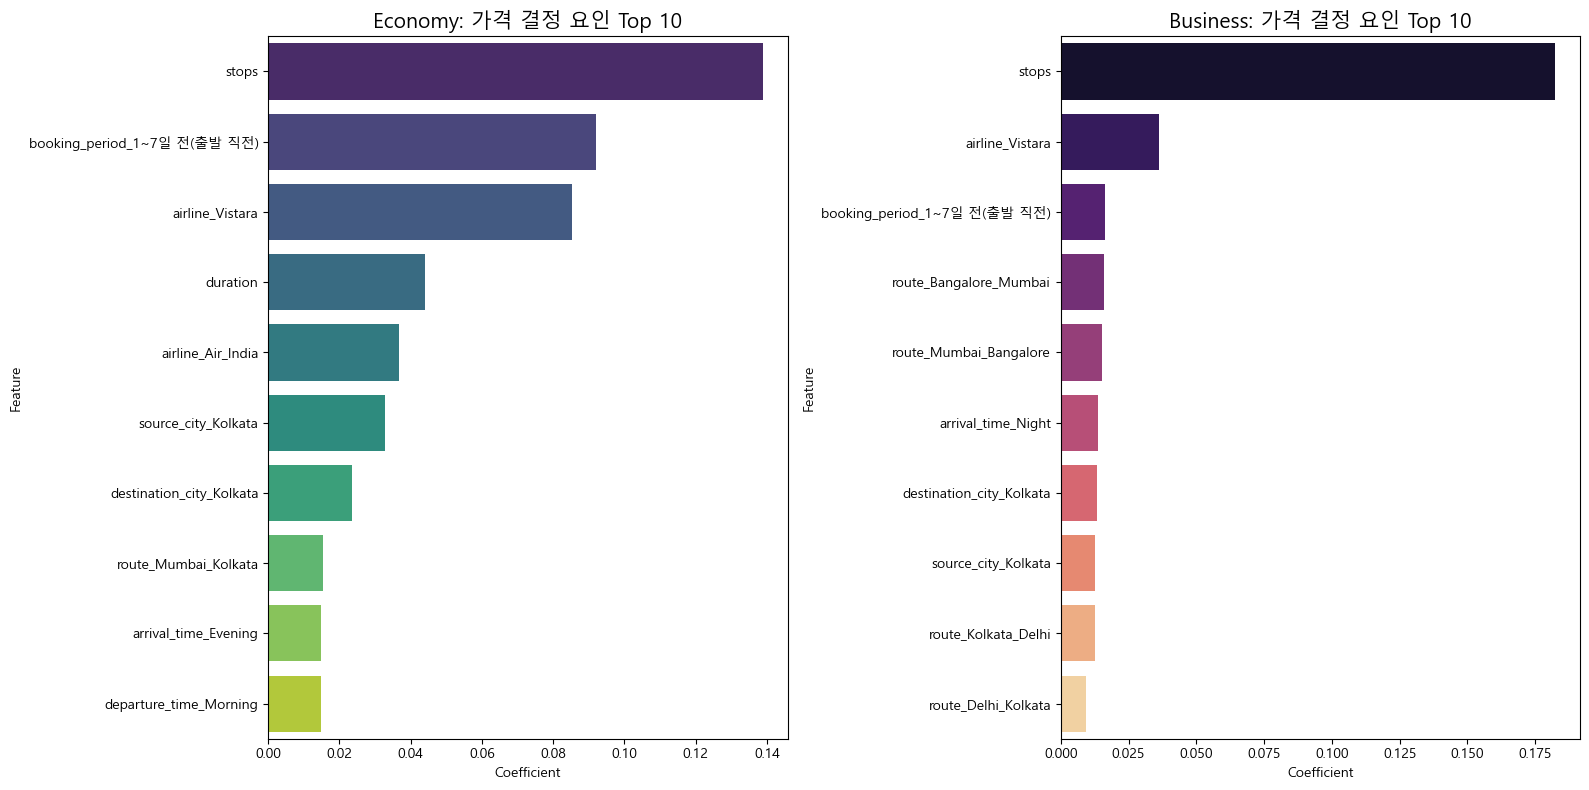

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 데이터 로드
df = pd.read_csv('final_preprocessed_data.csv')

# 2. 모델 학습 및 결과 추출 함수 (RMSE 추가 반환)
def get_model_results(target_df):
    # 인코딩 및 전처리
    X = pd.get_dummies(target_df.drop(columns=['price', 'class']))
    y = target_df['price']
    
    # 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 릿지 모델 학습
    model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
    model.fit(X_train_scaled, y_train)
    
    # 평가 지표 계산
    y_pred = model.predict(X_test_scaled)
    
    # 실제 가격 단위로 복원 (np.expm1)
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp)) # RMSE 추가
    
    # 계수(Coefficient) 데이터프레임 생성
    coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
    
    return r2, mae, rmse, coef_df

# 3. 각 클래스별 결과 얻기 (변수 4개씩 받기)
eco_r2, eco_mae, eco_rmse, eco_coef = get_model_results(df[df['class'] == 0])
bus_r2, bus_mae, bus_rmse, bus_coef = get_model_results(df[df['class'] == 1])

# --- 시각화 1: 가격 결정 요인 비교 (Coefficients) ---
plt.figure(figsize=(16, 8))

# 이코노미 Top 10
plt.subplot(1, 2, 1)
eco_top = eco_coef.sort_values(by='Coefficient', ascending=False).head(10)
sns.barplot(x='Coefficient', y='Feature', data=eco_top, hue='Feature', palette='viridis', legend=False)
plt.title('Economy: 가격 결정 요인 Top 10', fontsize=15)

# 비즈니스 Top 10
plt.subplot(1, 2, 2)
bus_top = bus_coef.sort_values(by='Coefficient', ascending=False).head(10)
sns.barplot(x='Coefficient', y='Feature', data=bus_top, hue='Feature', palette='magma', legend=False)
plt.title('Business: 가격 결정 요인 Top 10', fontsize=15)

plt.tight_layout()
plt.savefig('comparison_coefficients.png')


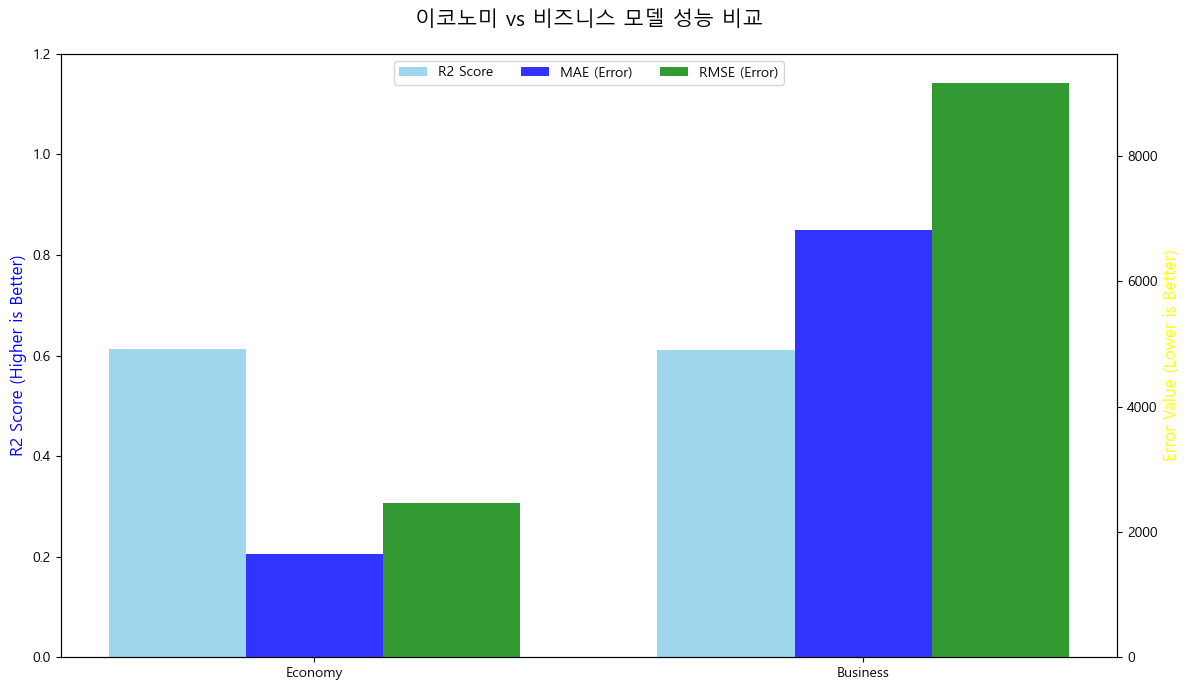

In [24]:
# --- 시각화 2: 모델 성능 비교 (Metrics) ---
# 1. 데이터 정의 (이전 단계에서 계산된 변수들 사용)
labels = ['Economy', 'Business']
r2_vals = [eco_r2, bus_r2]
mae_vals = [eco_mae, bus_mae]
rmse_vals = [eco_rmse, bus_rmse]

# 2. 도화지(Figure)와 축(Axes) 생성
fig, ax1 = plt.subplots(figsize=(12, 7))
x = np.arange(len(labels))
width = 0.25 

# 3. R2 Score 그리기 (왼쪽 축)
rects1 = ax1.bar(x - width, r2_vals, width, label='R2 Score', color='skyblue', alpha=0.8)
ax1.set_ylabel('R2 Score (Higher is Better)', color='blue', fontsize=12)
ax1.set_ylim(0, 1.2) 
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# 4. MAE & RMSE 그리기 (오른쪽 축)
ax2 = ax1.twinx()
rects2 = ax2.bar(x, mae_vals, width, label='MAE (Error)', color='blue', alpha=0.8)
rects3 = ax2.bar(x + width, rmse_vals, width, label='RMSE (Error)', color='green', alpha=0.8)
ax2.set_ylabel('Error Value (Lower is Better)', color='yellow', fontsize=12)

# 5. 디자인 및 범례 설정
plt.title('이코노미 vs 비즈니스 모델 성능 비교', fontsize=15, pad=20)

# 두 축의 범례를 하나로 합치기
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=3)

plt.tight_layout()

# [중요] 화면에 그래프를 출력하는 명령어
plt.show() 

# 파일로도 저장하고 싶다면 추가
# plt.savefig('comparison_metrics.png')